# Polarization Switching Example

Demonstrates time-dependent polarization switching between two microwave
polarization components using square waves with a phase offset
between the two microwave transitions, creating 4 distinct polarization states
per cycle.

Uses the `structured_upper` execution mode with the `dopri5` solver.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from centrex_tlf import transitions, couplings, lindblad
from centrex_tlf.lindblad.plan_static import prepare_lindblad_problem
from centrex_tlf.lindblad.solve import solve_lindblad

## Parameters

Adjust the switching frequency, phase offset between the two microwave transitions,
and the Rabi frequency for all transitions.

In [2]:
switching_frequency = 500e3
phase_offset = np.pi / 2
rabi_frequency = 2 * np.pi * 1e6

## System Setup

Set up the rotational cooling system with P(2) optical transition and
J=1→2 and J=2→3 microwave transitions, each with two polarization components.

In [3]:
P2 = transitions.OpticalTransition(transitions.OpticalTransitionType.P, 2, 3 / 2, 1)
J12 = transitions.MicrowaveTransition(1, 2)
J23 = transitions.MicrowaveTransition(2, 3)

transition_selectors = couplings.generate_transition_selectors(
    [P2, J12, J23],
    [
        [couplings.polarization_Z],
        [
            (couplings.polarization_X - couplings.polarization_Z).normalize(),
            couplings.polarization_Y,
        ],
        [
            (couplings.polarization_X + couplings.polarization_Z).normalize(),
            couplings.polarization_Y,
        ],
    ],
)

system = lindblad.generate_OBE_system_transitions(
    [P2, J12, J23], transition_selectors, method="matrix"
)

print(
    f"States: {len(system.QN)} ({len(system.ground)} ground + {len(system.excited)} excited)"
)

States: 67 (64 ground + 3 excited)


## Time-Dependent Parameters

`generate_lindblad_parameters` automatically sets up `square_wave(t, ω, φ)` based
polarization switching for microwave transitions with two polarization components.
The switching frequency and phase offset are controlled via the `ω` and `φ` base
parameters for each transition index.

In [4]:
params = lindblad.generate_lindblad_parameters(transition_selectors)

omega_switching = 2 * np.pi * switching_frequency
params.base_parameters["\u03c91"] = omega_switching
params.base_parameters["\u03c92"] = omega_switching
params.base_parameters["\u03c61"] = 0.0
params.base_parameters["\u03c62"] = phase_offset
params.base_parameters["\u03a9t0"] = rabi_frequency
params.base_parameters["\u03a9t1"] = rabi_frequency
params.base_parameters["\u03a9t2"] = rabi_frequency
params.base_parameters["\u03b40"] = 0.0
params.base_parameters["\u03b41"] = 0.0
params.base_parameters["\u03b42"] = 0.0

print("Base parameters:", dict(params.base_parameters))
print("Compound parameters:", dict(params.compound_parameters))

Base parameters: {'Ω0': (9801769.079200154+0j), 'δ0': 0.0, 'PZ0': (1+0j), 'Ω1': (9801769.079200154+0j), 'δ1': 0.0, 'ω1': 3141592.653589793, 'φ1': 0.0, 'Ω2': (9801769.079200154+0j), 'δ2': 0.0, 'ω2': 3141592.653589793, 'φ2': 1.5707963267948966, 'Ωt0': 6283185.307179586, 'Ωt1': 6283185.307179586, 'Ωt2': 6283185.307179586}
Compound parameters: {'PA1': 'square_wave(t, ω1, φ1)', 'PY1': '1 - PA1', 'PA2': 'square_wave(t, ω2, φ2)', 'PY2': '1 - PA2'}


## Prepare and Solve

In [14]:
prepared = prepare_lindblad_problem(system, params, backend="rust")

n = len(system.QN)
n_ground = len(system.ground)
rho0 = np.zeros((n, n), dtype=np.complex128)
for i in range(n_ground):
    rho0[i, i] = 1.0 / n_ground

t_span = (0.0, 200e-6)
n_points = 2001
saveat = np.linspace(t_span[0], t_span[1], n_points)

In [11]:
import time

t0 = time.perf_counter()
result = solve_lindblad(
    prepared,
    rho0,
    t_span,
    solver="dopri5",
    execution_mode="structured_upper",
    saveat=saveat,
    dt=1e-10,
    reltol=1e-7,
    abstol=1e-9,
)
elapsed = time.perf_counter() - t0
print(f"Solve time: {elapsed * 1000:.1f} ms")
print(f"Trace at end: {result.populations()[-1].sum():.6f}")

Solve time: 11066.5 ms
Trace at end: 1.000000


## Plot Results

In [7]:
populations = result.populations()
times_us = result.t * 1e6

j_labels = {}
for i, qn in enumerate(system.QN):
    largest = qn.largest
    j_val = largest.J
    label = f"J={j_val}"
    if i >= n_ground:
        label += " (excited)"
    if label not in j_labels:
        j_labels[label] = []
    j_labels[label].append(i)

j_populations = {}
for label, indices in j_labels.items():
    j_populations[label] = populations[:, indices].sum(axis=1)

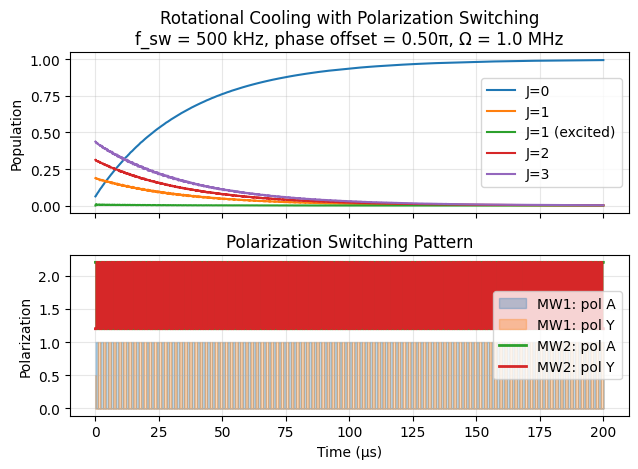

In [13]:
fig, axes = plt.subplots(2, 1, sharex=True)

ax1 = axes[0]
colors = plt.cm.tab10.colors
for idx, (label, pop) in enumerate(sorted(j_populations.items())):
    ax1.plot(times_us, pop, label=label, color=colors[idx % len(colors)], linewidth=1.5)
ax1.set_ylabel("Population")
ax1.set_title(
    f"Rotational Cooling with Polarization Switching\n"
    f"f_sw = {switching_frequency / 1e3:.0f} kHz, "
    f"phase offset = {phase_offset / np.pi:.2f}\u03c0, "
    f"\u03a9 = {rabi_frequency / (2 * np.pi * 1e6):.1f} MHz"
)
ax1.legend(loc="right")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.05)

ax2 = axes[1]
sw1 = np.array(
    [0.5 * (1.0 + np.sign(np.sin(omega_switching * t + 0.0))) for t in result.t]
)
sw2 = np.array(
    [
        0.5 * (1.0 + np.sign(np.sin(omega_switching * t + phase_offset)))
        for t in result.t
    ]
)
ax2.fill_between(
    times_us, 0, sw1, alpha=0.3, label="MW1: pol A", color="C0", step="mid"
)
ax2.fill_between(
    times_us, 0, 1 - sw1, alpha=0.3, label="MW1: pol Y", color="C1", step="mid"
)
ax2.plot(
    times_us,
    sw2 + 1.2,
    label="MW2: pol A",
    color="C2",
    linewidth=2,
    drawstyle="steps-mid",
)
ax2.plot(
    times_us,
    (1 - sw2) + 1.2,
    label="MW2: pol Y",
    color="C3",
    linewidth=2,
    drawstyle="steps-mid",
)
ax2.set_xlabel("Time (\u00b5s)")
ax2.set_ylabel("Polarization")
ax2.set_title("Polarization Switching Pattern")
ax2.legend(loc="right")
# ax2.set_ylim(-0.1, 1.9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()